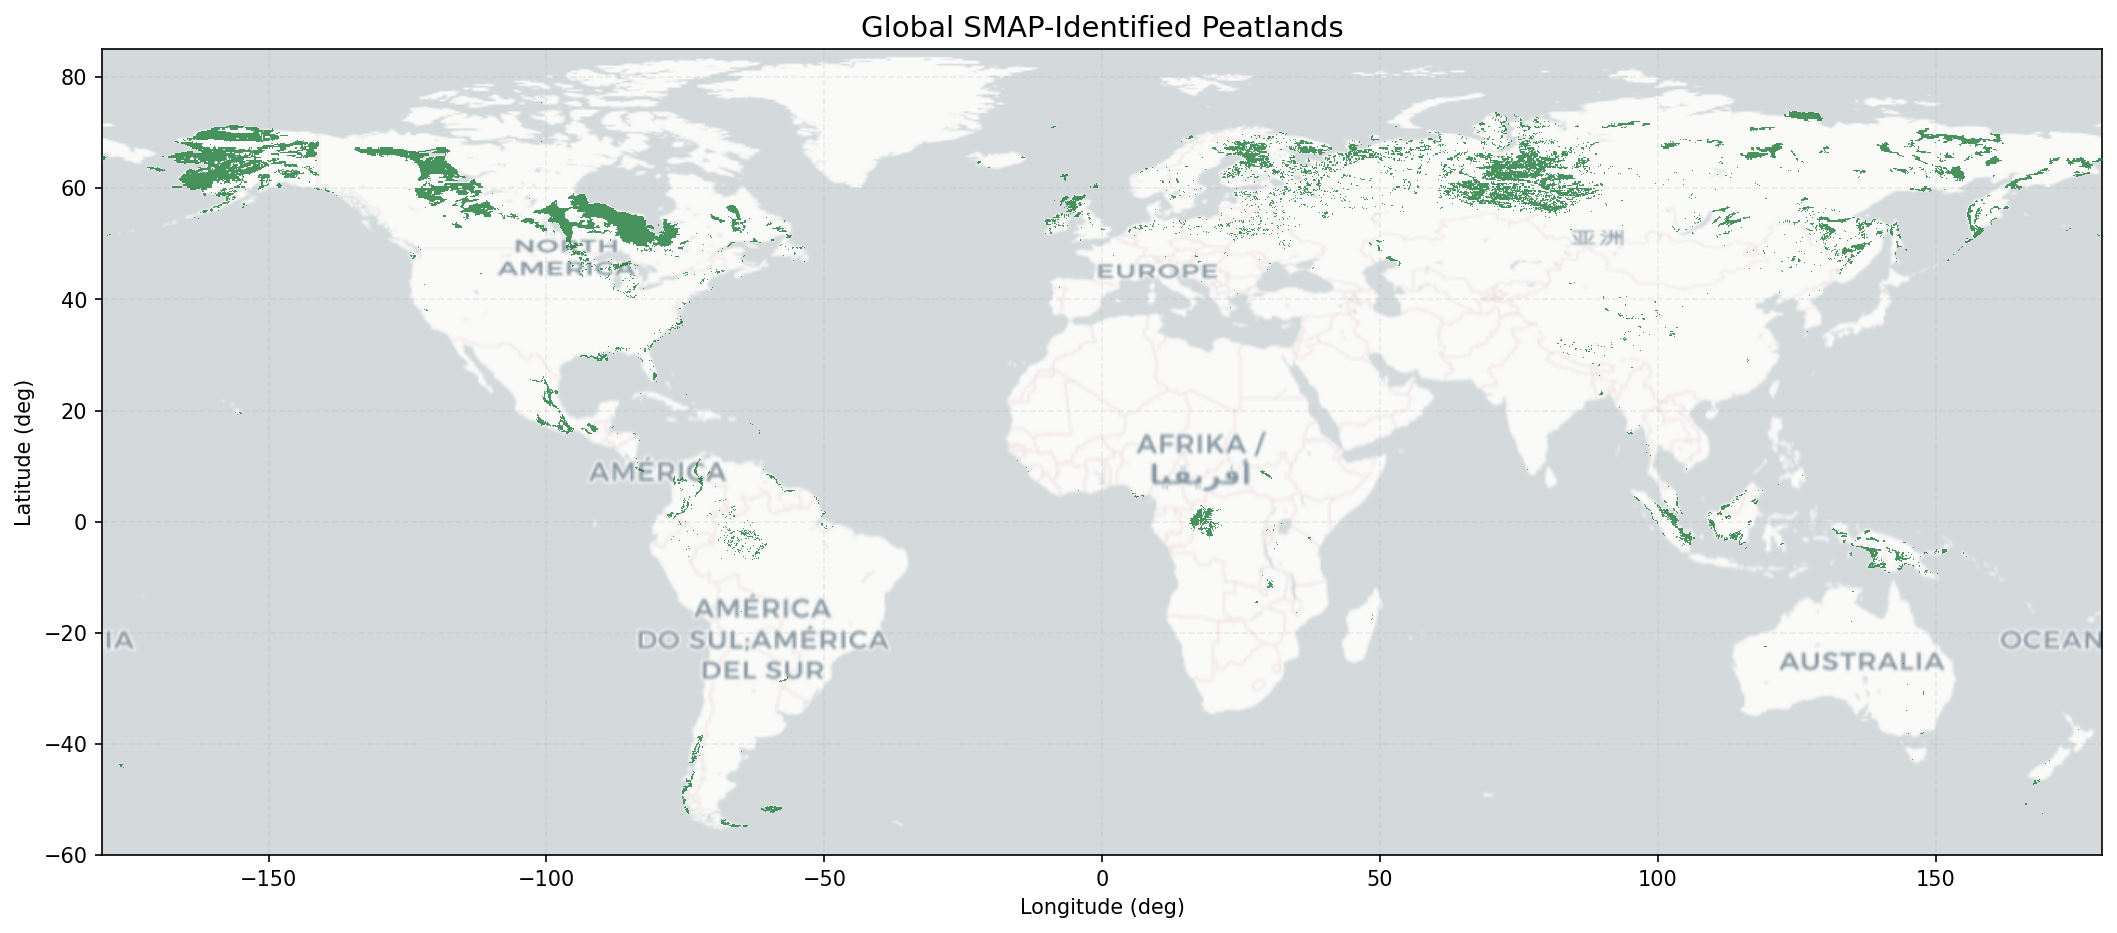

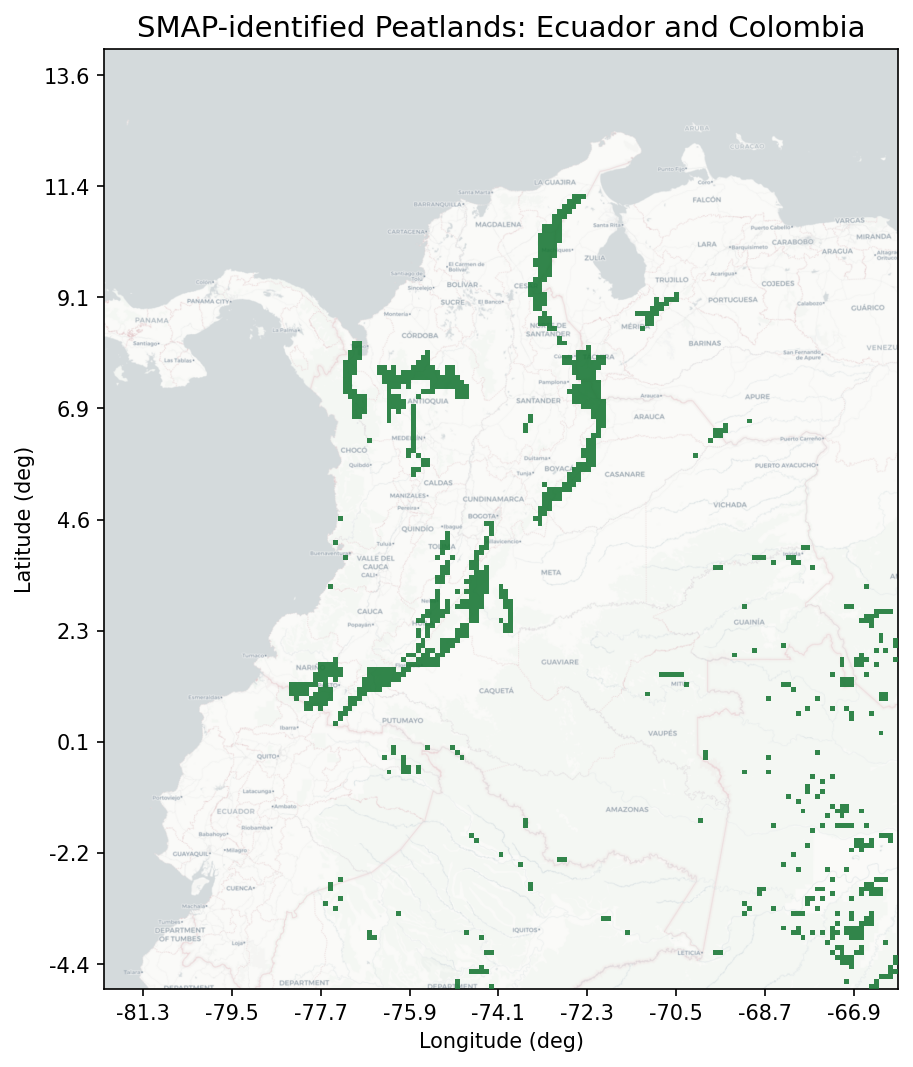

In [15]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter
from pyproj import Transformer
from rasterio.transform import array_bounds
from rasterio.windows import from_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling

peatmask_path = r"C:\Bachelorarbeit\NewSG\peatmask\SMAP_Peat_Mask3.tif"

if not os.path.exists(peatmask_path):
    raise FileNotFoundError(
        f"Could not find peatmask raster at: {peatmask_path}. "
        "Update 'peatmask_path' if your file is in a different location."
    )

zoom_lon_min, zoom_lon_max = -82, -66
zoom_lat_min, zoom_lat_max = -5, 14
close_crs = "EPSG:3116"  # MAGNA-SIRGAS / Colombia Bogota zone

with rasterio.open(peatmask_path) as src:
    data = src.read(1)
    if src.crs is None:
        raise ValueError("Raster CRS is missing; cannot map coordinates reliably.")
    if str(src.crs) != "EPSG:4326":
        raise ValueError(
            f"Expected EPSG:4326 raster, got {src.crs}. "
            "Please provide the peatmask in geographic coordinates."
        )

    # Build a binary peatmask so we can draw actual cells, not point centers.
    peat_global = np.where(np.isfinite(data) & (data > 0), 1, np.nan).astype(np.float32)
    if np.count_nonzero(np.isfinite(peat_global)) == 0:
        raise ValueError("No peatland pixels (>0) found in this raster.")

    bounds = src.bounds
    extent_global = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Extract only the Ecuador/Colombia window from the raster.
    win = from_bounds(zoom_lon_min, zoom_lat_min, zoom_lon_max, zoom_lat_max, src.transform)
    win = win.round_offsets().round_lengths()
    reg_data = src.read(1, window=win, boundless=True, fill_value=0)
    reg_transform = src.window_transform(win)
    peat_reg = np.where(np.isfinite(reg_data) & (reg_data > 0), 1, 0).astype(np.uint8)

# -------- Global map (lon/lat) --------
fig_global, ax_global = plt.subplots(figsize=(14, 6), dpi=150, constrained_layout=True)

# Draw true raster cells in geographic coordinates.
peat_cmap = ListedColormap(["#1b7837"])
ax_global.imshow(
    peat_global,
    extent=extent_global,
    origin="upper",
    interpolation="nearest",
    cmap=peat_cmap,
    alpha=0.8,
    zorder=3,
)
ax_global.set_xlim(-180, 180)
ax_global.set_ylim(-60, 85)
ax_global.set_xlabel("Longitude (deg)")
ax_global.set_ylabel("Latitude (deg)")
ax_global.set_title("Global SMAP-Identified Peatlands", fontsize=14)
ax_global.grid(alpha=0.2, linestyle="--")

try:
    cx.add_basemap(
        ax_global,
        source=cx.providers.CartoDB.Positron,
        crs="EPSG:4326",
        attribution=False,
        zoom=2,
    )
except Exception as e:
    print(f"Basemap warning (global): {e}")

plt.show()

# -------- Close-up map (projected raster pixels) --------
reg_h, reg_w = peat_reg.shape
reg_left, reg_bottom, reg_right, reg_top = array_bounds(reg_h, reg_w, reg_transform)
reg_bounds = (reg_left, reg_bottom, reg_right, reg_top)

dst_transform, dst_w, dst_h = calculate_default_transform(
    "EPSG:4326", close_crs, reg_w, reg_h, *reg_bounds
)
peat_reg_proj = np.zeros((dst_h, dst_w), dtype=np.uint8)
reproject(
    source=peat_reg,
    destination=peat_reg_proj,
    src_transform=reg_transform,
    src_crs="EPSG:4326",
    dst_transform=dst_transform,
    dst_crs=close_crs,
    src_nodata=0,
    dst_nodata=0,
    resampling=Resampling.nearest,
)

peat_reg_proj_plot = np.where(peat_reg_proj > 0, 1, np.nan).astype(np.float32)
dleft = dst_transform.c
dtop = dst_transform.f
dright = dleft + dst_transform.a * dst_w
dbottom = dtop + dst_transform.e * dst_h
extent_close = [dleft, dright, dbottom, dtop]
center_x = 0.5 * (dleft + dright)
center_y = 0.5 * (dbottom + dtop)
to_geo = Transformer.from_crs(close_crs, "EPSG:4326", always_xy=True)

fig_close, ax_close = plt.subplots(figsize=(12, 7), dpi=150, constrained_layout=True)
ax_close.imshow(
    peat_reg_proj_plot,
    extent=extent_close,
    origin="upper",
    interpolation="nearest",
    cmap=peat_cmap,
    alpha=0.9,
    zorder=3,
)
ax_close.set_title("SMAP-identified Peatlands: Ecuador and Colombia", fontsize=14)

def fmt_lon(x, _):
    lon, _lat = to_geo.transform(x, center_y)
    return f"{lon:.1f}"

def fmt_lat(y, _):
    _lon, lat = to_geo.transform(center_x, y)
    return f"{lat:.1f}"

ax_close.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
ax_close.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
ax_close.set_xlabel("Longitude (deg)")
ax_close.set_ylabel("Latitude (deg)")

try:
    cx.add_basemap(
        ax_close,
        source=cx.providers.CartoDB.Positron,
        crs=close_crs,
        attribution=False,
        zoom=7,
    )
except Exception as e:
    print(f"Basemap warning (close-up): {e}")

plt.show()